In [176]:
import math

import pandas as pd
import matplotlib.pyplot as plt

In [177]:
df_ablation = pd.read_csv('ablation/cidds/results/ablation.csv')
df_ablation.set_index('test_idx', inplace=True)
df_ablation.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score
test_idx,,,,,,,,,,
1,50,50,32,0.647546,0.789854,0.555769,0.459733,0.424555,0.470480,0.370556
2,50,50,64,0.844536,0.905167,0.940850,0.991800,0.991918,0.991692,0.991792
3,50,50,128,0.840618,0.924410,0.943813,0.994267,0.994444,0.994126,0.994261
4,50,100,32,0.734118,0.846472,0.545236,0.646933,0.713195,0.638886,0.609610
5,50,100,64,0.654675,0.883320,0.926600,0.977000,0.976947,0.977301,0.976994


In [178]:
df_ablation['media_auc'] = (df_ablation['flowmiagan_auc'] + df_ablation['domias_auc'] + df_ablation['dcr_auc'])/3
df_ablation['f1_X_auc'] = df_ablation['f1-score'] - df_ablation['media_auc']

df_ablation = df_ablation.sort_values(by=['f1_X_auc', 'f1-score'], ascending=[False, False])
df_ablation.head()

,n_iter,batch_size,n_units_hidden,flowmiagan_auc,domias_auc,dcr_auc,accuracy,precision,recall,f1-score,media_auc,f1_X_auc
test_idx,,,,,,,,,,,,
22,100,1000,32,0.642700,0.474304,0.453866,0.982133,0.982066,0.982414,0.982128,0.523623,0.458505
46,200,1000,32,0.569881,0.305065,0.792143,0.979533,0.979789,0.980076,0.979532,0.555697,0.423836
34,150,1000,32,0.565521,0.337367,0.506015,0.863400,0.888380,0.859921,0.860264,0.469634,0.390630
13,100,50,32,0.382098,0.915123,0.906177,0.958800,0.960833,0.958003,0.958673,0.734466,0.224208
12,50,1000,128,0.553215,0.832699,0.789576,0.934333,0.938494,0.935810,0.934283,0.725163,0.209120


### Valores de F1-Score, AUC do Domias, AUC do DCR e AUC do Flowmiagan para cada teste

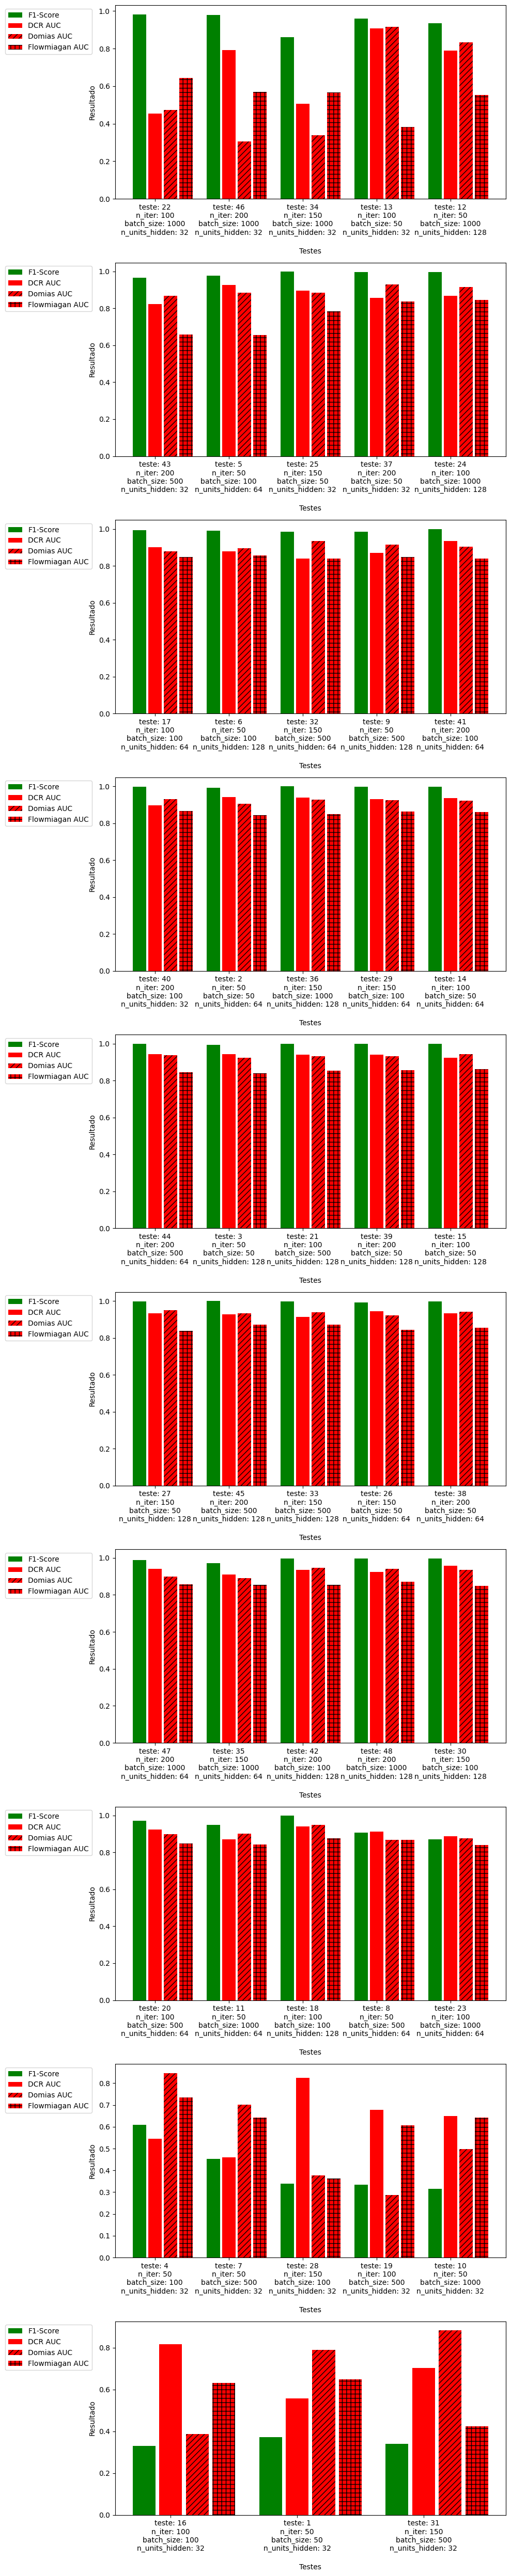

In [179]:
testes = df_ablation.index.tolist()
f1_scores = df_ablation['f1-score']
flowmiagan_auc = df_ablation['flowmiagan_auc']
dcr_auc = df_ablation['dcr_auc']
domias_auc = df_ablation['domias_auc']

columns_per_row = 5

total_rows = math.ceil(len(testes)/columns_per_row)

fig, ax = plt.subplots(figsize=(10,5*total_rows), ncols=1, nrows= total_rows)

largura = 0.18
espaco = 0.03

for i in range(total_rows):
    start = i*columns_per_row
    end = start + columns_per_row

    curr_testes = testes[start: end]
    curr_f1_scores = f1_scores[start: end]
    curr_dcr_auc = dcr_auc[start: end]
    curr_flowmiagan_auc = flowmiagan_auc[start:end]
    curr_domias_auc = domias_auc[start:end]

    indices = list(range(len(curr_testes)))
    ax[i].bar([x - largura - espaco for x in indices], curr_f1_scores, largura, label='F1-Score', color='green')
    
    b2 = ax[i].bar(indices, curr_dcr_auc, largura, label='DCR AUC', color='red')
    b3 = ax[i].bar([x + largura + espaco for x in indices], curr_domias_auc, largura, label='Domias AUC', color='red', hatch='///')
    b4 = ax[i].bar([x + 2*largura + 2*espaco for x in indices], curr_flowmiagan_auc, largura, label='Flowmiagan AUC', color='red', hatch='++')

    ax[i].set_xticks(indices)

    def parametros_em_label(test_idx):
        row = df_ablation.loc[test_idx]
        answer = f'teste: {test_idx}\n'
        answer += f'n_iter: {int(row['n_iter'])}\n'
        answer += f'batch_size: {int(row['batch_size'])}\n'
        answer += f'n_units_hidden: {int(row['n_units_hidden'])}\n'
        return answer

    ax[i].set_xticklabels([f'{parametros_em_label(x)}' for x in curr_testes])

    ax[i].set_xlabel('Testes')
    ax[i].set_ylabel('Resultado')

    ax[i].legend(bbox_to_anchor=(-0.05, 1), loc='upper right')
    

plt.tight_layout()
